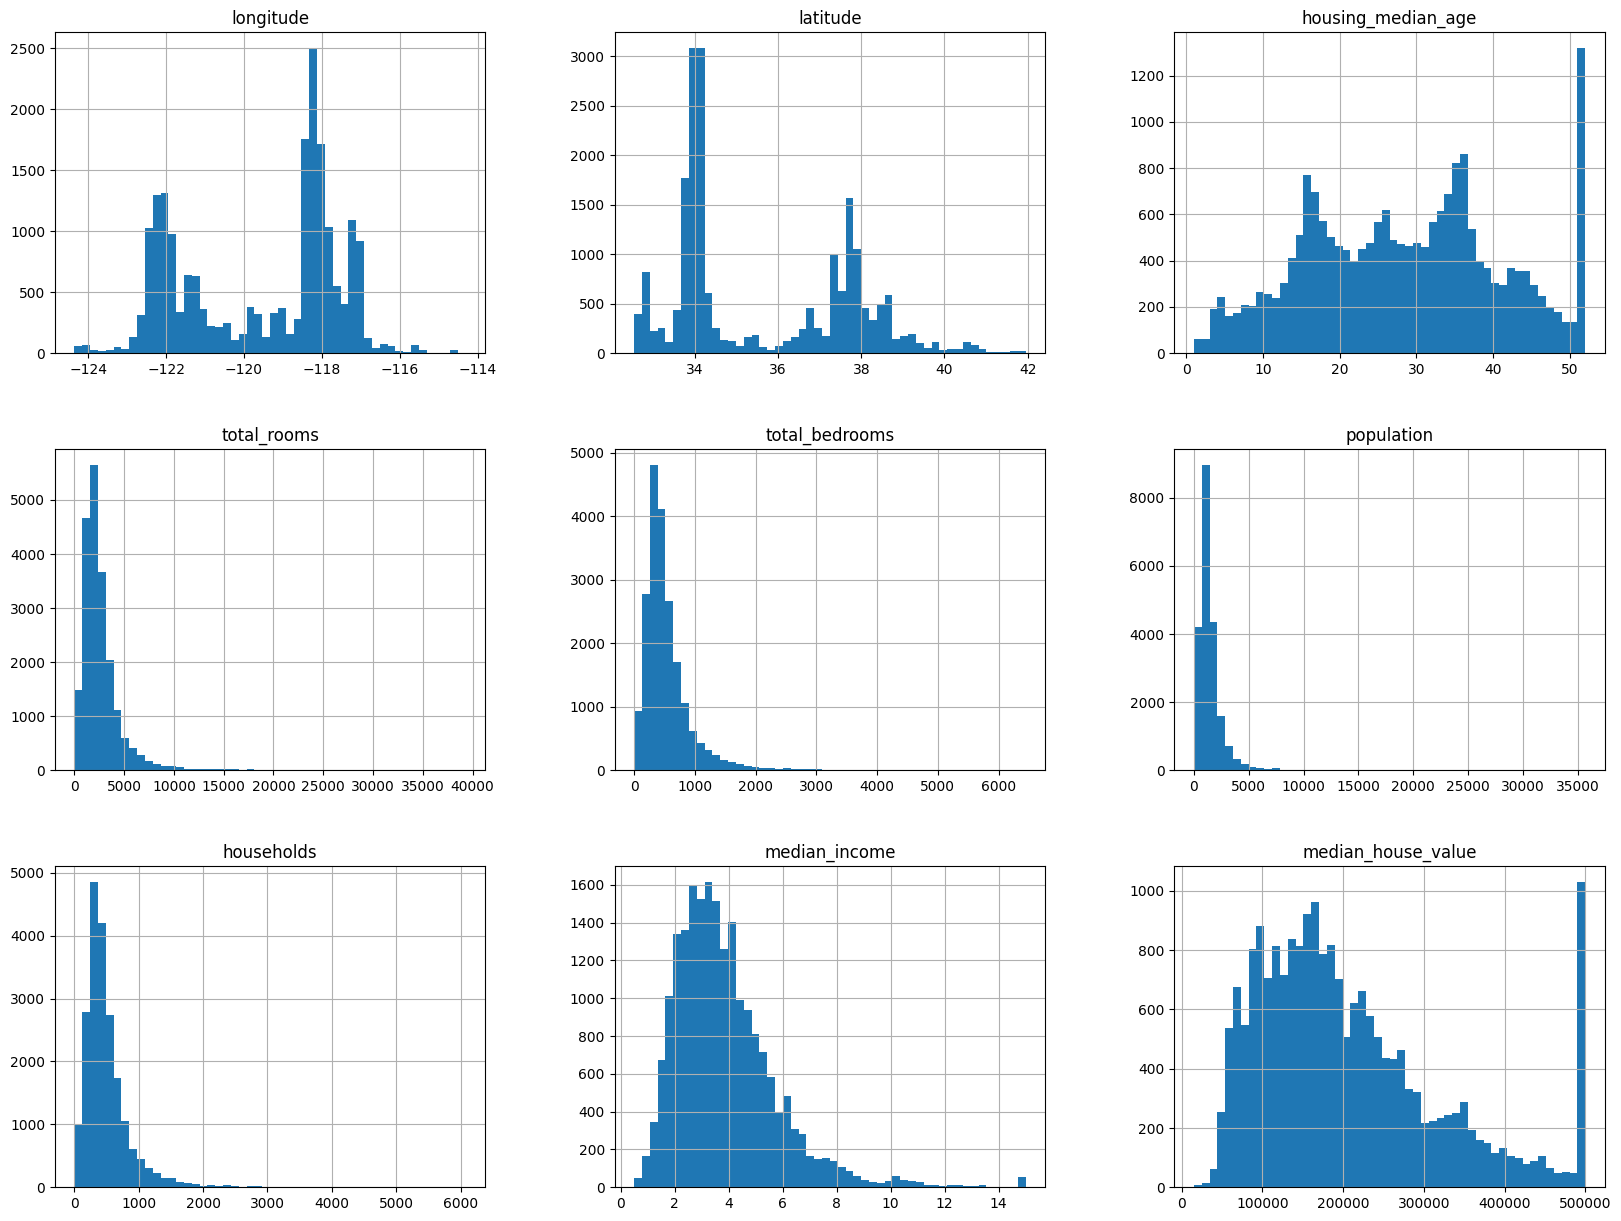

16512 train + 4128 test
16267 train + 4373 test
16512 train + 4128 test


,Overall,Random,Stratified,Rand %error,Strat %error
income_cat,,,,,
1.0,0.039826,0.040213,0.039971,0.973236,0.364964
2.0,0.318847,0.324370,0.318798,1.732260,-0.015195
3.0,0.350581,0.358527,0.350533,2.266446,-0.013820
4.0,0.176308,0.167393,0.176357,-5.056334,0.027480
5.0,0.114438,0.109496,0.114341,-4.318374,-0.084674


median_house_value    1.000000
median_income         0.687151
total_rooms           0.135140
housing_median_age    0.114146
households            0.064590
total_bedrooms        0.047781
population           -0.026882
longitude            -0.047466
latitude             -0.142673
Name: median_house_value, dtype: float64

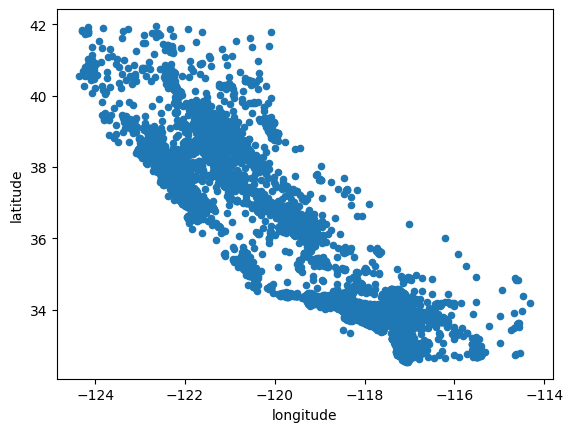

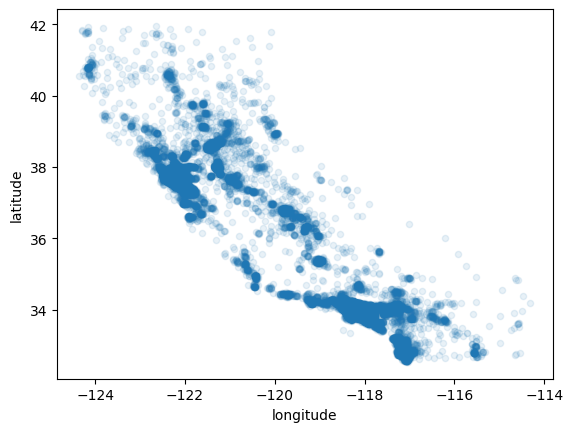

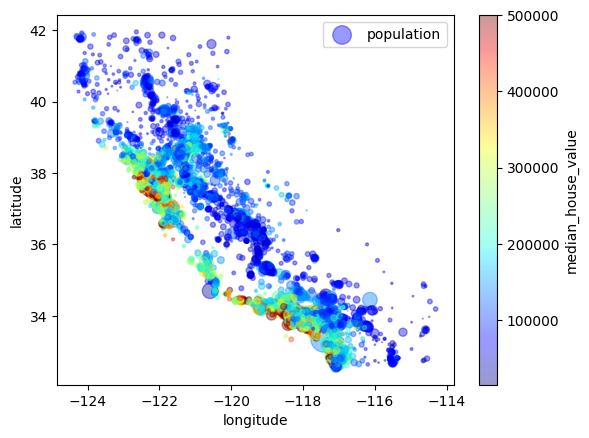

In [20]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np
import hashlib
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedShuffleSplit

# house path of the datasets
HOUSING_PATH = "datasets/housing"

# load the housing.csv
def load_housing_data(housing_path=HOUSING_PATH):
    csv_path = os.path.join(housing_path, "housing.csv")
    return pd.read_csv(csv_path)

# call the housing method
housing = load_housing_data(HOUSING_PATH)

housing.hist(bins=50, figsize=(20,15))
plt.show()

# split the train data
def split_train_test(data, test_ratio):
 shuffled_indices = np.random.permutation(len(data))
 test_set_size = int(len(data) * test_ratio)
 test_indices = shuffled_indices[:test_set_size]
 train_indices = shuffled_indices[test_set_size:]
 return data.iloc[train_indices], data.iloc[test_indices]

# get the test set thru checking
def test_set_check(identifier, test_ratio, hash):
 return hash(np.int64(identifier)).digest()[-1] < 256 * test_ratio

#get tge train test by id
def split_train_test_by_id(data, test_ratio, id_column, hash=hashlib.md5):
 ids = data[id_column]
 in_test_set = ids.apply(lambda id_: test_set_check(id_, test_ratio, hash))
 return data.loc[~in_test_set], data.loc[in_test_set]

train_set, test_set = split_train_test(housing, 0.2)
print(len(train_set), "train +", len(test_set), "test")

housing_with_id = housing.reset_index() # adds an `index` column
train_set, test_set = split_train_test_by_id(housing_with_id, 0.2, "index")

housing_with_id["id"] = housing["longitude"] * 1000 + housing["latitude"]
train_set, test_set = split_train_test_by_id(housing_with_id, 0.2, "id")

print(len(train_set), "train +", len(test_set), "test")

train_set, test_set = train_test_split(housing, test_size=0.2, random_state=42)
print(len(train_set), "train +", len(test_set), "test")

housing["income_cat"] = np.ceil(housing["median_income"] / 1.5)
housing["income_cat"] = housing["income_cat"].where(housing["income_cat"] < 5, 5.0)
housing["income_cat"].value_counts() / len(housing)

# Calculate overall proportions
overall_props = housing["income_cat"].value_counts(normalize=True).sort_index()

# Random split
train_set, test_set = train_test_split(housing, test_size=0.2, random_state=42)
random_props = test_set["income_cat"].value_counts(normalize=True).sort_index()

# Stratified split
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in split.split(housing, housing["income_cat"]):
    strat_test_set = housing.loc[test_index]
stratified_props = strat_test_set["income_cat"].value_counts(normalize=True).sort_index()

# Calculate percentage errors
rand_perc_error = 100 * (random_props - overall_props) / overall_props
strat_perc_error = 100 * (stratified_props - overall_props) / overall_props

# Combine into a DataFrame
comparison = pd.DataFrame({
    "Overall": overall_props,
    "Random": random_props,
    "Stratified": stratified_props,
    "Rand %error": rand_perc_error,
    "Strat %error": strat_perc_error
})

# Display the table
display(comparison)

# split
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

for train_index, test_index in split.split(housing, housing["income_cat"]):
 strat_train_set = housing.loc[train_index]
 strat_test_set = housing.loc[test_index]

for set in (strat_train_set, strat_test_set):
 set.drop(["income_cat"], axis=1, inplace=True)

housing = strat_train_set.copy()

# virtualize using scatter
housing.plot(kind="scatter", x="longitude", y="latitude")

# virtualize but we can identify which in area in san francisco is high and low
housing.plot(kind="scatter", x="longitude", y="latitude", alpha=0.1)

# Added a virtualize where you can see the median and the graph
housing.plot(kind="scatter", x="longitude", y="latitude", alpha=0.4,
 s=housing["population"]/100, label="population",
 c="median_house_value", cmap=plt.get_cmap("jet"), colorbar=True,
)
plt.legend()

corr_matrix = housing.select_dtypes(include=[np.number]).corr()
corr_matrix["median_house_value"].sort_values(ascending=False)